In [1]:
import os
import parse_labels
import dataset
import util

import importlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
import model
import importlib

importlib.reload(parse_labels)

# gets the labels
base_path = os.getcwd()
input_path = "raw_data/manifest-xxn3N2Qq630907925598003437/TCGA-KIRC"
all_dirs = os.listdir(input_path)


label_path = os.path.join(base_path, "raw_data", "labels.txt")
data_path = os.path.join(base_path, "raw_data", "manifest-xxn3N2Qq630907925598003437/TCGA-KIRC")

map = parse_labels.get_all_dcm_files(label_path, data_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [2]:
importlib.reload(model)

# Get patient scan series data (grouped by patient AND scan series)
series_data = parse_labels.get_all_dcm_files(label_path, data_path)
print(f"Found {len(series_data)} scan series total\n")

Found 2652 scan series total



In [ ]:
importlib.reload(util)
import math
# Preload scan series volumes into memory

DATA_SHAPE = (64, 192, 192)
print("Preloading scan series volumes...")
preloaded_data = util.preload_dcm_files(
    series_data, 
    crop=(100 * (1 - 1/math.sqrt(2)), 100 * (1 - 1/math.sqrt(2)), 0),
    target_shape=DATA_SHAPE,  # (Depth, Height, Width)
    max_files=None   # Start with small subset to test
)
print(f"Successfully preloaded {len(preloaded_data)} scan series volumes")


# Print grade count for each label
grade_counts = {}
for _, label, _ in preloaded_data.values():
    lbl = label.item()
    grade_counts[lbl] = grade_counts.get(lbl, 0) + 1

print("\nGrade count by label:")
for lbl in sorted(grade_counts.keys()):
    print(f"  Label {lbl} (Grade {lbl + 1}): {grade_counts[lbl]} samples")

Preloading scan series volumes...


Preloading Scan Series:  49%|████▉     | 1304/2652 [08:54<09:44,  2.31series/s]

In [4]:
from skimage import exposure
from scipy.ndimage import laplace
from tqdm import tqdm
import numpy as np
import torch
import os

# Process each scan volume
for key, (volume, label, patient_id) in tqdm(preloaded_data.items(), desc="Processing scan volumes"):
    # Extract top-left 3x3x3 cube and compute average brightness
    cube = volume[0, 0:3, 0:3, 0:3]
    avg_brightness = torch.mean(cube).item()
    
    # Invert if average brightness > 128
    if avg_brightness >= 128:
        volume = 256 - volume
    
    processed_volume = volume.float()
    
    # Normalize to 0-1 range for skimage processing
    if processed_volume.max() > 0:
        processed_volume = processed_volume / processed_volume.max()
    
    # Convert to numpy and remove channel dimension [1, D, H, W] -> [D, H, W]
    processed_volume_np = processed_volume[0].cpu().numpy()
    
    # 1. Laplacian Sharpening
    lap = laplace(processed_volume_np)
    sharpened_volume = processed_volume_np - 0.3 * lap
    
    # 2. Histogram Equalization
    equalized_volume = exposure.equalize_hist(sharpened_volume)
    
    # Add the channel dimension back
    final_volume_np = np.expand_dims(equalized_volume, axis=0)
    
    # Convert back to tensor and 0-255 range
    final_volume = torch.from_numpy(final_volume_np).float() * 255
    preloaded_data[key] = (final_volume, label, patient_id)

# Save the preprocessed data directly
save_path = os.path.join(base_path, "preloaded_data_processed.pt")
print(f"Saving preprocessed data to {save_path}...")
torch.save(preloaded_data, save_path)
print("Data successfully saved.")

Processing scan volumes:   0%|          | 0/1883 [00:00<?, ?it/s]

Processing scan volumes: 100%|██████████| 1883/1883 [02:46<00:00, 11.30it/s]


Saving preprocessed data to /home/petedowney/github/KidneyCancerPrediction/preloaded_data_processed.pt...
Data successfully saved.


In [5]:
# save_path = os.path.join(base_path, "preloaded_data_processed.pt")
# preloaded_data = torch.load(save_path)


In [6]:
import numpy as np

print(f"Original preloaded_data size: {len(preloaded_data)}")



# 2. Duplicate Class 2 (now Label 0) and Class 4 (now Label 2) to match Class 3 (now Label 1)
# First, count current labels
counts = {}
for _, label, _ in preloaded_data.values():
    lbl = label.item()
    counts[lbl] = counts.get(lbl, 0) + 1

target_count = max(counts.values())

print(f"Target count: {target_count}")

# Duplicate data
new_idx = max(preloaded_data.keys()) + 1 if preloaded_data else 0


for label_to_augment in range(1, 4):
    current_count = counts.get(label_to_augment, 0)
    if 0 < current_count < target_count:
        needed = target_count - current_count
        # Get all keys for this class
        class_keys = [k for k, v in preloaded_data.items() if v[1].item() == label_to_augment]
        
        # Randomly sample 'needed' times with replacement
        augmented_keys = np.random.choice(class_keys, size=needed, replace=True)
        
        for aug_key in augmented_keys:
            volume, label, patient_id = preloaded_data[aug_key]
            # Add to preloaded_data with a new strictly incrementing key
            preloaded_data[new_idx] = (volume, label, f"{patient_id}_aug")
            new_idx += 1
            
print(f"New preloaded_data size after duplication: {len(preloaded_data)}")

# Output label breakdown to verify
print("\nFinal Label breakdown in preloaded_data:")
final_counts = {}
for _, label, _ in preloaded_data.values():
    lbl = label.item()
    final_counts[lbl] = final_counts.get(lbl, 0) + 1

for lbl in sorted(final_counts.keys()):
    print(f"  Internal Label {lbl} (Grade {lbl + 1}): {final_counts[lbl]} samples")

Original preloaded_data size: 1883
Target count: 788
New preloaded_data size after duplication: 2380

Final Label breakdown in preloaded_data:
  Internal Label 0 (Grade 1): 16 samples
  Internal Label 1 (Grade 2): 788 samples
  Internal Label 2 (Grade 3): 788 samples
  Internal Label 3 (Grade 4): 788 samples


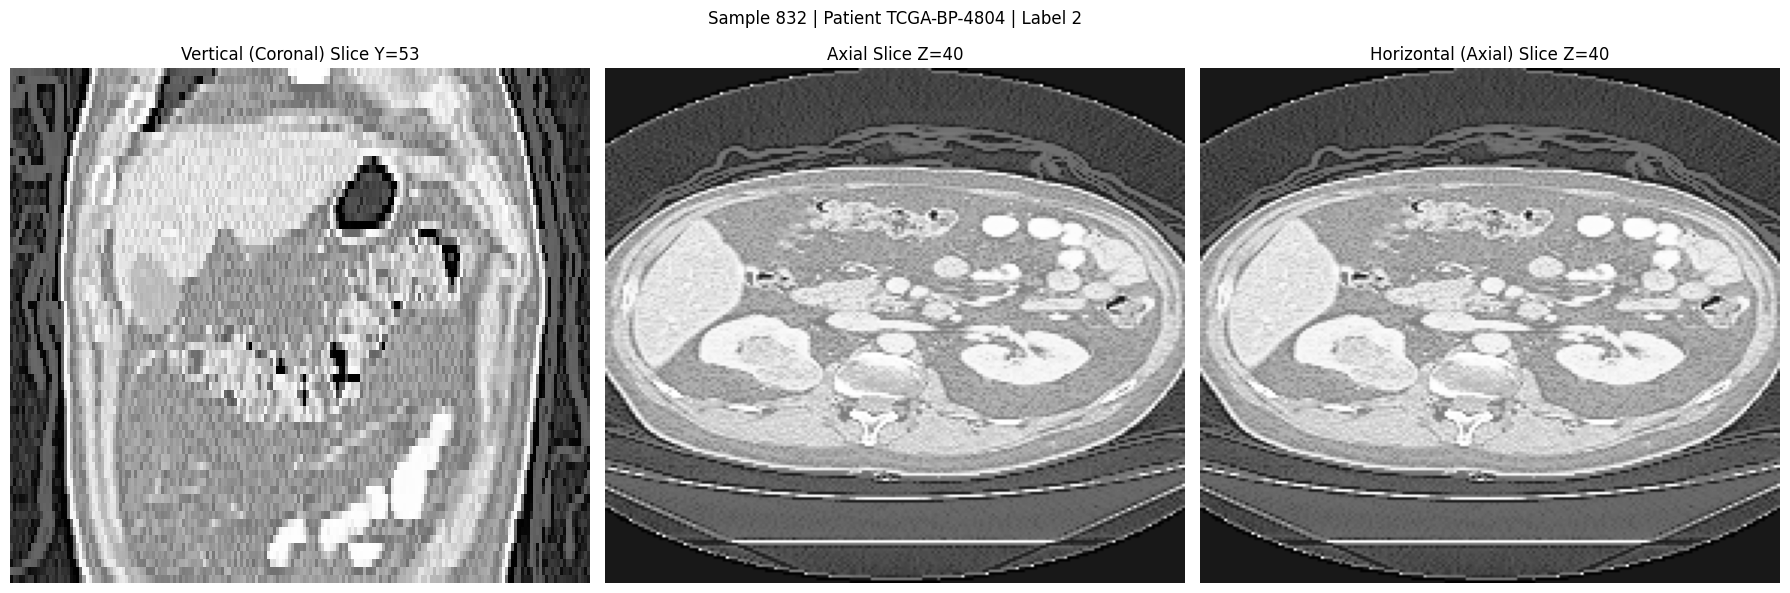

In [7]:
import matplotlib.pyplot as plt

# Pick a random preloaded scan and display slices
sample_idx = np.random.choice(list(preloaded_data.keys()))
volume, label, patient_id = preloaded_data[sample_idx]

# volume shape is expected to be [C, D, H, W] matches [C, Z, Y, X]
depth, height, width = volume.shape[1], volume.shape[2], volume.shape[3]

slice_idx_z = np.random.randint(0, depth)   # Horizontal (Axial) plane slice
slice_idx_y = np.random.randint(0, height)  # Vertical (Coronal) plane slice

vol_np = volume[0].cpu().numpy()

# Note on dimensions:
# vol_np is shaped [Z, Y, X] (Depth, Height, Width)

# Vertical (Coronal) plane: fix Y, plot Z vs X
show_img_one = vol_np[:, slice_idx_y, :]

# "Sharpened" (Axial) plane: fix Z, plot Y vs X 
show_img_two = vol_np[slice_idx_z, :, :]

# Horizontal (Axial) plane: fix Z, plot Y vs X
slice_img_horizontal = vol_np[slice_idx_z, :, :]

# Scale visuals for displaying
show_img_one = (show_img_one - show_img_one.min()) / (show_img_one.max() - show_img_one.min() + 1e-8)
show_img_two = (show_img_two - show_img_two.min()) / (show_img_two.max() - show_img_two.min() + 1e-8)
slice_img_horizontal = (slice_img_horizontal - slice_img_horizontal.min()) / (slice_img_horizontal.max() - slice_img_horizontal.min() + 1e-8)

# w1 is Width (X). w2 is the Height (Z-axis scale in the Coronal plane)
# show_img_horizontal shape is [Y, X], show_img_one shape is [Z, X]
w_axial = slice_img_horizontal.shape[1] # X dimension
w_coronal = show_img_one.shape[1] # X dimension
# For proper subplot aspect ratios based on image widths:
w1, w2 = w_axial, w_coronal

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [w_coronal, w_axial, w_axial]})

# 1. Vertical Coronal (Z vs X) -> Extent is narrow vertically because Z is 64, X is 256
axes[0].imshow(show_img_one, cmap="gray", aspect='auto')
axes[0].set_title(f"Vertical (Coronal) Slice Y={slice_idx_y}")
axes[0].axis("off")

# 2. Sharpened Axial (Y vs X) -> 256x256 square
axes[1].imshow(show_img_two, cmap="gray", aspect='auto')
axes[1].set_title(f"Axial Slice Z={slice_idx_z}")
axes[1].axis("off")

# 3. Standard Axial (Y vs X) -> 256x256 square
axes[2].imshow(slice_img_horizontal, cmap="gray", aspect='auto')
axes[2].set_title(f"Horizontal (Axial) Slice Z={slice_idx_z}")
axes[2].axis("off")

plt.suptitle(f"Sample {sample_idx} | Patient {patient_id} | Label {label.item() + 1}")
plt.tight_layout()
plt.show()

In [8]:
importlib.reload(dataset)

# Create 80/20 train/validation split
train_size = int(0.8 * len(preloaded_data))
indices = list(range(len(preloaded_data)))
np.random.seed(42)
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

print(f"Train scan series: {len(train_indices)}")
print(f"Val scan series: {len(val_indices)}\n")

# Convert preloaded data to uint8 before passing to dataset
to_uint8_data = {}
for key, (vol, lbl, pid) in preloaded_data.items():
    # Convert from float (0-1) to uint8 (0-255)
    uint8_vol = (vol * 255).to(torch.uint8)
    to_uint8_data[key] = (uint8_vol, lbl, pid)


# Create dataloaders
train_dataset = dataset.DCMDataset(series_data, DATA_SHAPE, preloaded_data=to_uint8_data)
val_dataset = dataset.DCMDataset(series_data, DATA_SHAPE, preloaded_data=to_uint8_data)

print(f"Train dataset size: {train_dataset.print_memory_usage() / (1024**2):.2f} MB")
print(f"Validation dataset size: {val_dataset.print_memory_usage() / (1024**2):.2f} MB")

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=3, shuffle=True, num_workers=3, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_subset, batch_size=3, shuffle=True, num_workers=3, pin_memory=True
)

# Check dataset sizes
print(f"Train subset size: {len(train_subset)}")
print(f"Val subset size: {len(val_subset)}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch: {len(val_loader)}\n")

Train scan series: 1904
Val scan series: 476

Train dataset size: 5355.16 MB
Validation dataset size: 5355.16 MB
Train subset size: 1904
Val subset size: 476
Train batches per epoch: 635
Val batches per epoch: 159



In [9]:
importlib.reload(model)

# Initialize model
net = model.SimpleCNN(num_classes=4, input_shape=DATA_SHAPE).to(device)

print(f"Model parameter memory usage: {net.print_memory_usage() / (1024**2):.2f} MB")

data_mem = train_dataset.print_memory_usage() + val_dataset.print_memory_usage()
model_mem = net.print_memory_usage()

print(f"Total memory usage: {model_mem / (1024**2) + data_mem / (1024**2):.2f} MB")
# Train the model
history = net.train_model(
    train_loader, 
    val_loader, 
    device, 
    num_epochs=20, 
    learning_rate=0.0001
)

Model parameter memory usage: 4.19 MB
Total memory usage: 10714.51 MB


Epoch 1/20 Val: 100%|██████████| 159/159 [00:17<00:00,  9.03batch/s]


Train Loss: 1.1684 | Train Acc: 34.66% | Val Loss: 1.1146 | Val Acc: 41.81%


Epoch 2/20 Val: 100%|██████████| 159/159 [00:18<00:00,  8.80batch/s]


Train Loss: 1.1315 | Train Acc: 37.13% | Val Loss: 1.0953 | Val Acc: 42.86%


Epoch 3/20 Train:   4%|▍         | 25/635 [00:14<05:58,  1.70batch/s]


KeyboardInterrupt: 

In [ ]:
import gc
import torch

if device.type == 'cuda':
    # 1. Force Python's Garbage Collector to delete unreferenced variables
    gc.collect()

    # 2. Force PyTorch to empty its VRAM cache
    torch.cuda.empty_cache()

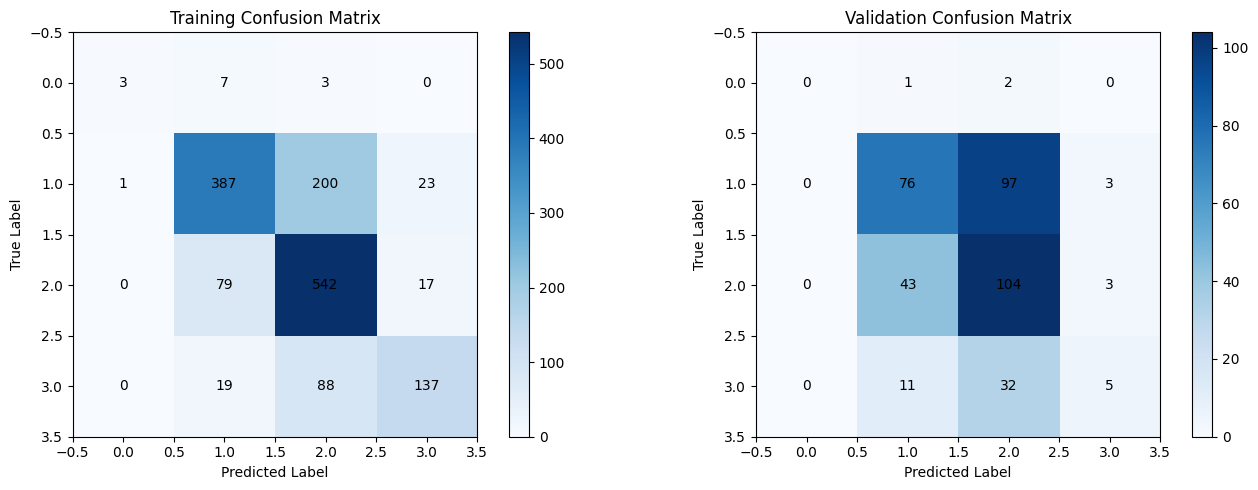

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get predictions for training data
train_preds = []
train_true = []
net.eval()
with torch.no_grad():
    for images, labels, _ in train_loader:
        images = images.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

# Get predictions for validation data
val_preds = []
val_true = []
with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_true.extend(labels.cpu().numpy())

# Create confusion matrices
train_cm = confusion_matrix(train_true, train_preds)
val_cm = confusion_matrix(val_true, val_preds)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
im1 = axes[0].imshow(train_cm, cmap='Blues')
axes[0].set_title('Training Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
for i in range(train_cm.shape[0]):
    for j in range(train_cm.shape[1]):
        axes[0].text(j, i, str(train_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im1, ax=axes[0])

# Validation confusion matrix
im2 = axes[1].imshow(val_cm, cmap='Blues')
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
for i in range(val_cm.shape[0]):
    for j in range(val_cm.shape[1]):
        axes[1].text(j, i, str(val_cm[i, j]), ha='center', va='center', color='black')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

#SMOT

In [ ]:
# Save the trained model
model_path = os.path.join(base_path, "kidney_cancer_modelMax.pth")
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to /home/petedowney/github/KidneyCancerPrediction/kidney_cancer_model2k.pth


In [ ]:
net = model.SimpleCNN(num_classes=4, input_shape=DATA_SHAPE).to(device)
model_path = os.path.join(base_path, "kidney_cancer_model2k.pth")
# Load the model from the saved path
net.load_state_dict(torch.load(model_path))

# Train for another set amount of epochs
additional_epochs = 15
history_continued = net.train_model(
    train_loader, 
    val_loader, 
    device, 
    num_epochs=additional_epochs, 
    learning_rate=0.00005 # slightly lower learning rate for continued training
)


torch.save(net.state_dict(), os.path.join(base_path, "kidney_cancer_model2kB.pth"))

/tmp/ipykernel_15877/4137669577.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(model_path))
Epoch 1/15 Val: 100%|██████████| 126/126 [00:

Train Loss: 0.7199 | Train Acc: 71.91% | Val Loss: 1.1040 | Val Acc: 43.24%


Epoch 2/15 Val: 100%|██████████| 126/126 [00:10<00:00, 12.20batch/s]


Train Loss: 0.5079 | Train Acc: 83.93% | Val Loss: 1.1318 | Val Acc: 45.09%


Epoch 3/15 Val: 100%|██████████| 126/126 [00:10<00:00, 12.51batch/s]


...

Train Loss: 0.0029 | Train Acc: 100.00% | Val Loss: 1.8923 | Val Acc: 43.24%


Epoch 14/15 Val: 100%|██████████| 126/126 [00:09<00:00, 13.29batch/s]


Train Loss: 0.0018 | Train Acc: 100.00% | Val Loss: 2.0098 | Val Acc: 44.03%


Epoch 15/15 Val: 100%|██████████| 126/126 [00:09<00:00, 13.31batch/s]


Train Loss: 0.0014 | Train Acc: 100.00% | Val Loss: 2.0313 | Val Acc: 45.09%
Training complete!
